# Работа производилась в kaggle
Функции были перенесены из репозитория в кагл, для возможности использовать GPU

Установка зависимостей

In [1]:
# !pip uninstall ffmpeg -y
# !pip uninstall ffmpeg-python -y
# !pip uninstall python-ffmpeg -y

# # 2. Install the correct package

In [2]:
!pip install ffmpeg-python soundfile

Прячем логи незначительных ошибок

In [3]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

функции для открытия stem, и перевод их в waveform

In [4]:
import soundfile as sf
import ffmpeg
import numpy as np
import tensorflow as tf
import random

import io
import os

# Частота дискретизации
GLOBAL_RATE = 44100

# длинна аудио
CHUNK_SEC = 5
NUM_CHUNKS = 6
# Кол-во сэмплов для обучния
CONV_SIZE = 16
CHUNK_SAMPLES = GLOBAL_RATE * CHUNK_SEC 
CHUNK_SAMPLES += (CONV_SIZE - CHUNK_SAMPLES % CONV_SIZE) % CONV_SIZE

FRAME_LENGTH = 1024
FRAME_STEP = 256

# параметр отвечающий за размер свертки / развертки модели (нужен для корректной работы encoder / decoder)



def extract_audio_to_memory(input_file, track_index='0:a:0'):
    """
    Вытащить нужный stem из .wav/.stem.m4a в память (bytes)
    """
    process = (
        ffmpeg
        .input(input_file)
        .output('pipe:', format='wav', acodec='pcm_f32le', ar=44100, ac=1, map=track_index)
        .run_async(pipe_stdout=True, pipe_stderr=True)
    )

    out, err = process.communicate()

    if process.returncode != 0:
        raise RuntimeError(err.decode())
    return out


def load_audio_from_memory(audio_bytes, mono=True):   
    """
        Преобразовать Аудио в waveform / sample rate
    """ 
    audio_buffer = io.BytesIO(audio_bytes)
    waveform, sample_rate = sf.read(audio_buffer, dtype="float32")
    
    if waveform.ndim > 1 and mono:
        waveform = np.mean(waveform, axis=1)

    if len(waveform.shape) == 2:
        waveform = waveform.T
    return waveform, sample_rate


def load_audio(input_file, track_index='0:a:0', mono=True):
    """
        Загрузить нужный стем канал в формате waveform / sample rate
    """
    out = extract_audio_to_memory(input_file, track_index)
    mix_waveform, sr = load_audio_from_memory(out, mono)
    return mix_waveform, sr


def random_chunk(*tracks):
    """
        обрезает треки до необходимого кол-ва секунд
    """
    length = min(len(t) for t in tracks)

    if length <= CHUNK_SAMPLES:
        result = []
        for track in tracks:
            pad = CHUNK_SAMPLES - len(track)
            result.append(np.pad(track, (0, pad)))
        return result

    start = random.randint(0, length - CHUNK_SAMPLES)
    end = start + CHUNK_SAMPLES

    return [track[start:end] for track in tracks]


def load_song(input_path):
    """
        Вспомогательная функция: загрузка всех каналов
        0:a:0 mix
        0:a:1 drums
        0:a:2 bass
        0:a:3 other
        0:a:4 vocals
    """
    mix, _ = load_audio(input_path, "0:a:0")
    drums, _ = load_audio(input_path, "0:a:1")
    bass, _ = load_audio(input_path, "0:a:2")
    other, _ = load_audio(input_path, "0:a:3")
    vocals, _ = load_audio(input_path, "0:a:4")

    return mix, drums, bass, other, vocals


def normalize(*channels):        
    peak = max(
        np.max(np.abs(channel)) for channel in channels
    )
    peak = max(peak, 1e-8)
    
    return tuple(channel / peak for channel in channels)


def data_gen(path, track_idx=1):
    songs_list = sorted(f for f in os.listdir(path) if f.endswith(".wav") or f.endswith(".stem.mp4"))
    for song in songs_list:
        full_name = os.path.join(path, song)
        mix, drums, bass, other, vocals = load_song(full_name)
        for _ in range(NUM_CHUNKS):
            mix_c, drums_c, bass_c, other_c, vocals_c = random_chunk(mix, drums, bass, other, vocals)
            mix_c, drums_c, bass_c, other_c, vocals_c = normalize(mix_c, drums_c, bass_c, other_c, vocals_c)
            
            target = np.stack([drums_c, bass_c, other_c, vocals_c], axis=-1).astype(np.float32)
        
            yield mix_c[..., None].astype(np.float32), target

E0000 00:00:1781861121.973009    4299 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781861122.098945    4299 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781861123.070969    4299 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781861123.071007    4299 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781861123.071010    4299 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781861123.071012    4299 computation_placer.cc:177] computation placer already registered. Please check linka

функции для сохранения песен в формате npz (сейчас используется окно в 7 секунд и 5 сэмплов из одной песни)

In [5]:
def preprocess_song_to_tfrecord(input_path, writer):
    mix, drums, bass, other, vocals = load_song(input_path)

    mix, drums, bass, other, vocals = normalize(
        mix, drums, bass, other, vocals
    )

    for _ in range(NUM_CHUNKS):
        mix_c, d, b, o, v = random_chunk(mix, drums, bass, other, vocals)

        features = {
            "mix": tf.train.Feature(float_list=tf.train.FloatList(value=mix_c)),
            "drums": tf.train.Feature(float_list=tf.train.FloatList(value=d)),
            "bass": tf.train.Feature(float_list=tf.train.FloatList(value=b)),
            "other": tf.train.Feature(float_list=tf.train.FloatList(value=o)),
            "vocals": tf.train.Feature(float_list=tf.train.FloatList(value=v)),
        }

        example = tf.train.Example(features=tf.train.Features(feature=features))
        writer.write(example.SerializeToString())


feature_desc = {
    "mix": tf.io.FixedLenFeature([CHUNK_SAMPLES], tf.float32),
    "drums": tf.io.FixedLenFeature([CHUNK_SAMPLES], tf.float32),
    "bass": tf.io.FixedLenFeature([CHUNK_SAMPLES], tf.float32),
    "other": tf.io.FixedLenFeature([CHUNK_SAMPLES], tf.float32),
    "vocals": tf.io.FixedLenFeature([CHUNK_SAMPLES], tf.float32),
}

def parse_example(example_proto):
    x = tf.io.parse_single_example(example_proto, feature_desc)

    mix = tf.expand_dims(x["mix"], -1)

    y = tf.stack([
        x["drums"],
        x["bass"],
        x["other"],
        x["vocals"]
    ], axis=-1)

    return mix, y

функция создания датасета 

In [6]:
output_signature=(
    tf.TensorSpec(shape=(None, None, 1), dtype=tf.float32),
    tf.TensorSpec(shape=(None, None, 4), dtype=tf.float32), # target_waveform [samples, channels]
)

def create_dataset(tfrecord_path, batch_size=2):
    ds = tf.data.TFRecordDataset(tfrecord_path)

    ds = ds.map(
        parse_example,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.shuffle(1024)
    ds = ds.batch(batch_size, drop_remainder=True)

    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

объявление путей

In [7]:
root = "/kaggle/input/datasets/dhruvpatel1057/musdb18/musdb18"

data_path = root
test_data = data_path + "/test"
train_data = data_path + "/train"

процесс записвания стем в npz

In [8]:
writer = tf.io.TFRecordWriter("dataset.tfrecord")
song_name_list = os.listdir(train_data)
with tf.io.TFRecordWriter("dataset.tfrecord") as writer:
    for idx, song in enumerate(song_name_list):
        print(f"{idx + 1} / {len(song_name_list)}", end="\r", flush=False)
        preprocess_song_to_tfrecord(os.path.join(train_data, song), writer)

проверка, что датасет работает

In [9]:
from IPython.display import Audio
dataset = create_dataset("dataset.tfrecord", 1)
first_batch = list(dataset.take(1))[0]
# mix, target, sr = first_batch
mix, target = first_batch

print("✅ Dataset works!")
print(f"Mix - shape: {mix.shape}, dtype: {mix.dtype}")
print(f"Target - shape: {target.shape}, dtype: {target.dtype}")
# print(f"Sample rate: {sr.numpy()}")
print(f"Mix range: [{mix.numpy().min():.3f}, {mix.numpy().max():.3f}]")

# Now display audio
# display(Audio(mix[0].numpy(), rate=GLOBAL_RATE))
# display(Audio(target[0].numpy(), rate=GLOBAL_RATE))

I0000 00:00:1781861660.993219    4299 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781861660.999298    4299 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


✅ Dataset works!
Mix - shape: (1, 220512, 1), dtype: <dtype: 'float32'>
Target - shape: (1, 220512, 4), dtype: <dtype: 'float32'>
Mix range: [-0.706, 0.590]


функция создания модели
с 4-мя слоями энкодера / декоера

In [25]:
from tensorflow.keras.layers import Conv1D, Conv1DTranspose, Input, BatchNormalization, Activation, MaxPooling1D, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def create_model():
    conv_input = Input(shape=(None, 1))

    # first block
    x = Conv1D(16, 3, padding="same")(conv_input)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv1D(16, 3, padding="same")(x)
    x = BatchNormalization()(x)

    block_1_out = Activation("relu")(x)
    x = MaxPooling1D(pool_size=2)(block_1_out)

    # scnd block
    x = Conv1D(32, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv1D(32, 3, padding="same")(x)
    x = BatchNormalization()(x)
    block_2_out = Activation("relu")(x)
    x = MaxPooling1D(pool_size=2)(block_2_out)

    # third block
    x = Conv1D(64, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv1D(64, 3, padding="same")(x)
    x = BatchNormalization()(x)

    block_3_out = Activation("relu")(x)
    x = MaxPooling1D(pool_size=2)(block_3_out)

    # fourth block
    x = Conv1D(128, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv1D(128, 3, padding="same")(x)
    x = BatchNormalization()(x)

    block_4_out = Activation("relu")(x)
    x = MaxPooling1D(pool_size=2)(block_4_out)

    # middle block
    x = Conv1D(128, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    # x = MaxPooling1D(pool_size=3)(x)

    # first up
    x = Conv1DTranspose(128, 2, strides=2, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = concatenate([x, block_4_out])
    x = Conv1D(128, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    # second up
    x = Conv1DTranspose(64, 2, strides=2, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = concatenate([x, block_3_out])
    x = Conv1D(64, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    # third up
    x = Conv1DTranspose(32, 3, strides=2, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = concatenate([x, block_2_out])
    x = Conv1D(32, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    # fourth up
    x = Conv1DTranspose(16, 3, strides=2, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = concatenate([x, block_1_out])
    x = Conv1D(16, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv1D(4, 1, padding='same')(x)

    model = Model(conv_input, x)                                             # Создаем модель с входом 'img_input' и выходом 'x'

    # Компилируем модель
    model.compile(optimizer=Adam(learning_rate=1e-5),
                  loss='mse',
                  metrics=['mse'])

    # Возвращаем сформированную модель
    return model

создание / визуализация / обучение модели

In [26]:
model = create_model()
from tensorflow.keras import utils
# utils.plot_model(model, show_shapes=True, dpi = 80)

In [27]:
history = model.fit(dataset, epochs=20)

Epoch 1/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 51s 49ms/step - loss: 0.3910 - mse: 0.3910
Epoch 2/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 31s 47ms/step - loss: 0.1621 - mse: 0.1621
Epoch 3/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 31s 48ms/step - loss: 0.0753 - mse: 0.0753
Epoch 4/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 31s 48ms/step - loss: 0.0425 - mse: 0.0425
Epoch 5/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 31s 47ms/step - loss: 0.0274 - mse: 0.0274
Epoch 6/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 31s 47ms/step - loss: 0.0196 - mse: 0.0196
Epoch 7/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 31s 48ms/step - loss: 0.0150 - mse: 0.0150
Epoch 8/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 31s 47ms/step - loss: 0.0121 - mse: 0.0121
Epoch 9/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 31s 48ms/step - loss: 0.0101 - mse: 0.0101
Epoch 10/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 31s 48ms/step - loss: 0.0087 - mse: 0.0087
Epoch 11/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - loss: 0.0076 - mse: 0.0076
Epoch 12/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 31s 48ms/step - loss: 0.0069 - mse: 0.0069
E

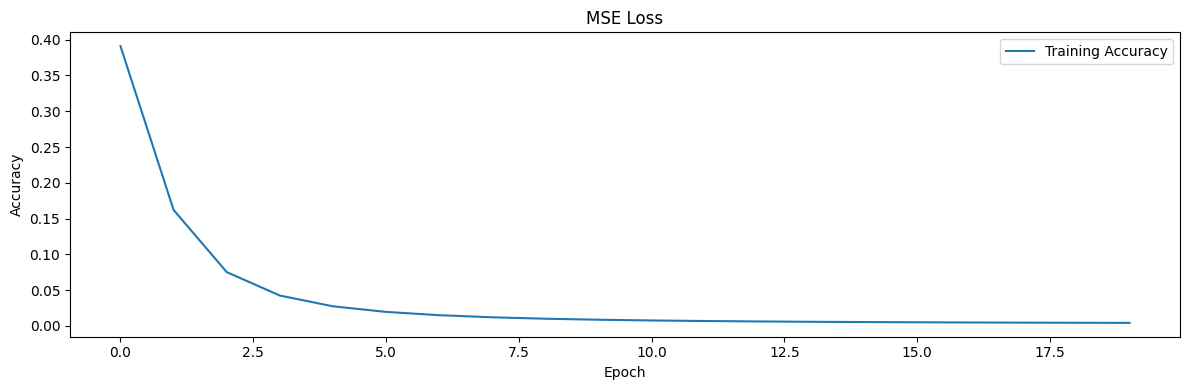

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))

plt.plot(history.history['mse'], label='Training Accuracy')

plt.title('MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# # 3. Plot Training & Validation Loss
# plt.subplot(1, 2, 2)
# plt.plot(history.history['loss'], label='Training Loss')
# plt.title('Model Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()

plt.tight_layout()
plt.show()

сохранение модели, для возможного локального использования

In [29]:
model.save("first.keras")

функции для проверки качества модели (модель делает предсказания по небольшим кускам, потом это собирается в одну дорожку)

In [30]:
import tensorflow as tf
import numpy as np

CHUNK_SAMPLES += (CONV_SIZE - CHUNK_SAMPLES % CONV_SIZE) % CONV_SIZE


def make_chunks(audio, chunk_size, hop_size):
    chunks = []
    for start in range(0, len(audio) - chunk_size + 1, hop_size):
        chunks.append(audio[start:start + chunk_size])
    return chunks
    

def overlap_add(chunks, hop_size, total_len):

    output = np.zeros((total_len,4),dtype=np.float32)
    weights = np.zeros(total_len,dtype=np.float32)

    window=np.hanning(len(chunks[0])).astype(np.float32)

    for i,chunk in enumerate(chunks):

        start=i*hop_size
        end=start+len(window)

        output[start:end]+=chunk*window[:,None]
        weights[start:end]+=window

    output/=np.maximum(weights[:,None],1e-8)

    return output


def predict_full(audio, model):

    chunk_size = CHUNK_SAMPLES
    hop_size = CHUNK_SAMPLES // 2

    chunks = make_chunks(
        audio,
        chunk_size,
        hop_size
    )

    preds=[]

    for chunk in chunks:

        x=chunk.astype(np.float32)

        x=x[:,None]

        x=x[None,...]

        pred=model.predict(
            x,
            verbose=0
        )[0]

        preds.append(pred)

    total_len=hop_size*(len(preds)-1)+chunk_size

    stems=overlap_add(
        preds,
        hop_size,
        total_len
    )

    return stems

обработка аудио модели

In [31]:
audio, sr = sf.read("/kaggle/input/datasets/mikhaildolgov/just-pretend/BAD OMENS - Just Pretend.mp3", dtype="float32")

if audio.ndim > 1:
    audio = np.mean(audio, axis=1)
    
pred = predict_full(audio, model)

sf.write(
    "drums.wav",
    pred[:,0],
    44100
)

sf.write(
    "bass.wav",
    pred[:,1],
    44100
)

sf.write(
    "other.wav",
    pred[:,2],
    44100
)

sf.write(
    "vocals.wav",
    pred[:,3],
    44100
)

[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?


в итоге получилось 4 аудио
вокал, барабаны, остальное, бас
mse сосотавило 0.0039
субъективное ощущение от работы модели:
с текущей реализацией разделение аудио не принесло бы никакого видимого толку 
у модели немного получилось выявить ударные партии, т.к это всплески импульсов
у остальных 3-х каналов свосем не получилось выявить необходимую информацию
следующими шагами будет изменение датасета -> переход на stft